# Hierarchy Aggregation Data Visualization

This notebook provides comprehensive visualizations of the hierarchy classification data from different Qwen model combinations across various recipes.


In [40]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All libraries imported successfully!")


All libraries imported successfully!


In [55]:
# Load and preprocess the data
df = pd.read_csv('sym_GPT4nano_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (100, 5)

Columns: ['recipe', 'model_combination', 'fuzzy_hierarchy', 'no_hierarchy', 'clear_hierarchy']

First few rows:


,recipe,model_combination,fuzzy_hierarchy,no_hierarchy,clear_hierarchy
0,baked_pumpkin_slices,Qwen_Qwen3-1.7B_Qwen_Qwen3-1.7B,10,0,0
1,baked_pumpkin_slices,Qwen_Qwen3-1.7B_Qwen_Qwen3-14B,6,0,4
2,baked_pumpkin_slices,Qwen_Qwen3-1.7B_Qwen_Qwen3-32B,7,0,3
3,baked_pumpkin_slices,Qwen_Qwen3-1.7B_Qwen_Qwen3-4B,7,0,3
4,baked_pumpkin_slices,Qwen_Qwen3-1.7B_Qwen_Qwen3-8B,7,0,3


In [56]:
# Data preprocessing and feature engineering

# Extract model sizes from model combination names
def extract_model_info(model_combo):
    parts = model_combo.split('_')
    model1_size = parts[1].replace('Qwen3-', '')
    model2_size = parts[3].replace('Qwen3-', '')
    return model1_size, model2_size

df[['model1_size', 'model2_size']] = df['model_combination'].apply(
    lambda x: pd.Series(extract_model_info(x))
)

# Define proper ordering for model sizes
model_size_order = ['1.7B', '4B', '8B', '14B', '32B']

# Convert model sizes to categorical with proper ordering
df['model1_size'] = pd.Categorical(df['model1_size'], categories=model_size_order, ordered=True)
df['model2_size'] = pd.Categorical(df['model2_size'], categories=model_size_order, ordered=True)

# Calculate total outcomes and percentages
df['total_outcomes'] = df['fuzzy_hierarchy'] + df['no_hierarchy'] + df['clear_hierarchy']
df['fuzzy_pct'] = (df['fuzzy_hierarchy'] / df['total_outcomes']) * 100
df['no_hierarchy_pct'] = (df['no_hierarchy'] / df['total_outcomes']) * 100
df['clear_pct'] = (df['clear_hierarchy'] / df['total_outcomes']) * 100

# Create hierarchy score (clear=2, fuzzy=1, no=0)
df['hierarchy_score'] = (df['clear_hierarchy'] * 2 + df['fuzzy_hierarchy'] * 1) / df['total_outcomes']

# Check if models are the same or different
df['same_model'] = df['model1_size'] == df['model2_size']

print("Data preprocessing completed!")
print(f"\nUnique recipes: {df['recipe'].unique()}")
print(f"Model sizes in order: {model_size_order}")
df.head()


Data preprocessing completed!

Unique recipes: ['baked_pumpkin_slices' 'boiled_corn_slices' 'boiled_green_bean_slices'
 'boiled_potato_slices']
Model sizes in order: ['1.7B', '4B', '8B', '14B', '32B']


,recipe,model_combination,fuzzy_hierarchy,no_hierarchy,clear_hierarchy,model1_size,model2_size,total_outcomes,fuzzy_pct,no_hierarchy_pct,clear_pct,hierarchy_score,same_model
0,baked_pumpkin_slices,Qwen_Qwen3-1.7B_Qwen_Qwen3-1.7B,10,0,0,1.7B,1.7B,10,100.0,0.0,0.0,1.0,True
1,baked_pumpkin_slices,Qwen_Qwen3-1.7B_Qwen_Qwen3-14B,6,0,4,1.7B,14B,10,60.0,0.0,40.0,1.4,False
2,baked_pumpkin_slices,Qwen_Qwen3-1.7B_Qwen_Qwen3-32B,7,0,3,1.7B,32B,10,70.0,0.0,30.0,1.3,False
3,baked_pumpkin_slices,Qwen_Qwen3-1.7B_Qwen_Qwen3-4B,7,0,3,1.7B,4B,10,70.0,0.0,30.0,1.3,False
4,baked_pumpkin_slices,Qwen_Qwen3-1.7B_Qwen_Qwen3-8B,7,0,3,1.7B,8B,10,70.0,0.0,30.0,1.3,False


## 1. Overview Heatmaps


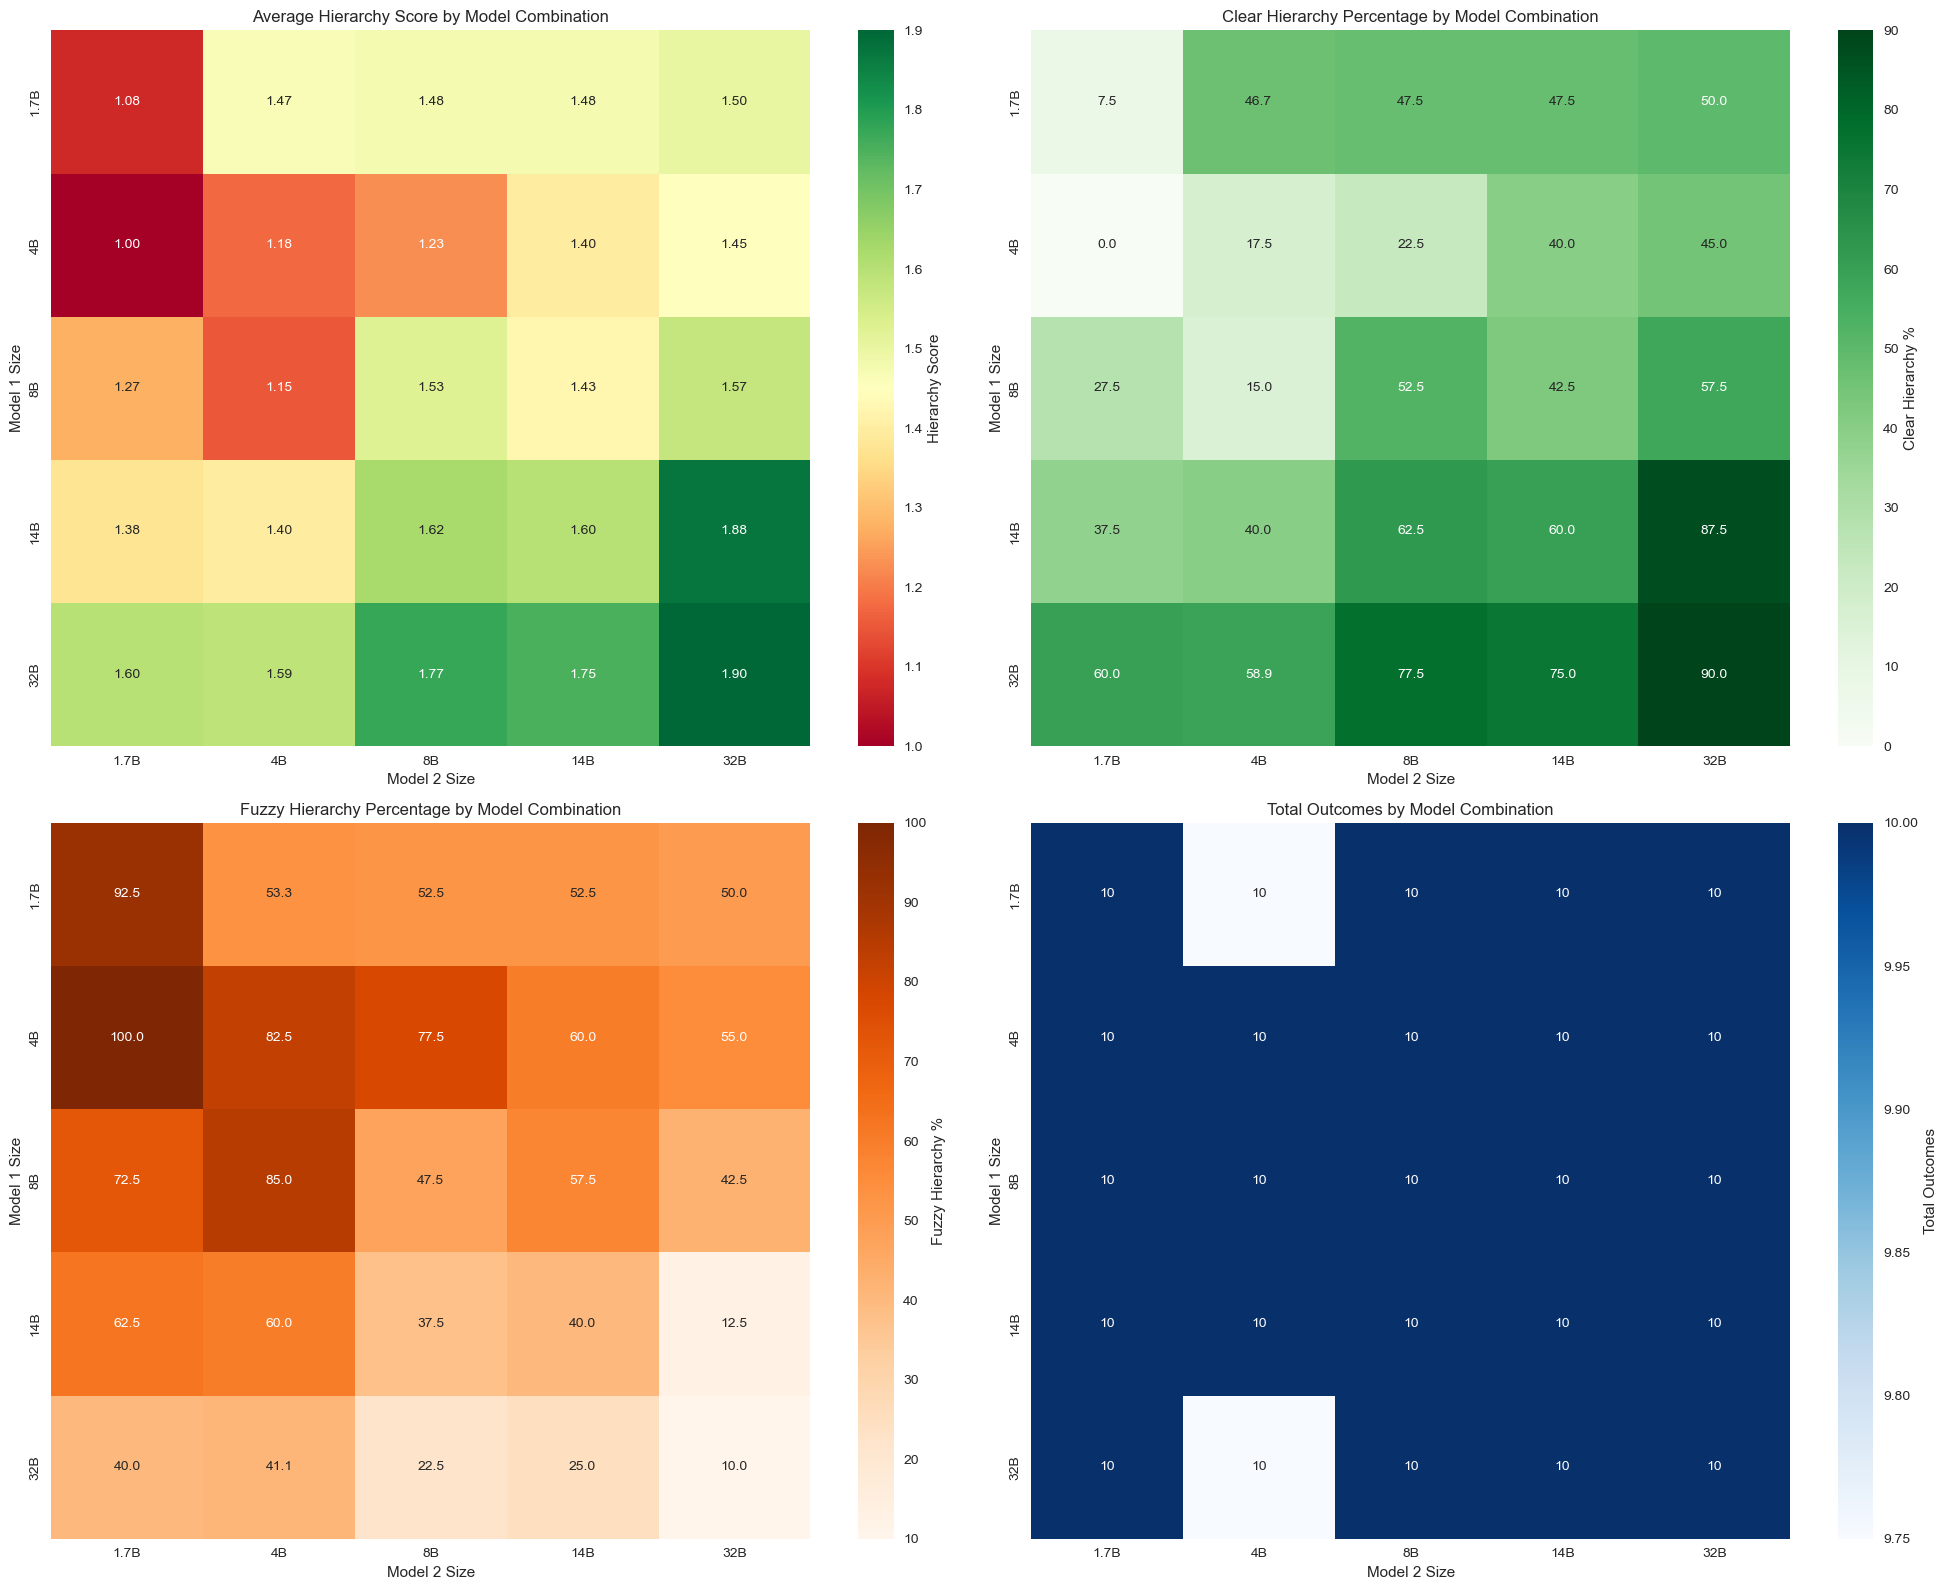

In [57]:
# 1. Hierarchy Score Heatmap
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Pivot data for heatmaps with proper ordering
hierarchy_matrix = df.pivot_table(
    values='hierarchy_score', 
    index='model1_size', 
    columns='model2_size', 
    aggfunc='mean'
).reindex(index=model_size_order, columns=model_size_order)

clear_matrix = df.pivot_table(
    values='clear_pct', 
    index='model1_size', 
    columns='model2_size', 
    aggfunc='mean'
).reindex(index=model_size_order, columns=model_size_order)

fuzzy_matrix = df.pivot_table(
    values='fuzzy_pct', 
    index='model1_size', 
    columns='model2_size', 
    aggfunc='mean'
).reindex(index=model_size_order, columns=model_size_order)

total_matrix = df.pivot_table(
    values='total_outcomes', 
    index='model1_size', 
    columns='model2_size', 
    aggfunc='mean'
).reindex(index=model_size_order, columns=model_size_order)

# Plot heatmaps
sns.heatmap(hierarchy_matrix, annot=True, fmt='.2f', cmap='RdYlGn', 
            ax=axes[0,0], cbar_kws={'label': 'Hierarchy Score'})
axes[0,0].set_title('Average Hierarchy Score by Model Combination')
axes[0,0].set_xlabel('Model 2 Size')
axes[0,0].set_ylabel('Model 1 Size')

sns.heatmap(clear_matrix, annot=True, fmt='.1f', cmap='Greens', 
            ax=axes[0,1], cbar_kws={'label': 'Clear Hierarchy %'})
axes[0,1].set_title('Clear Hierarchy Percentage by Model Combination')
axes[0,1].set_xlabel('Model 2 Size')
axes[0,1].set_ylabel('Model 1 Size')

sns.heatmap(fuzzy_matrix, annot=True, fmt='.1f', cmap='Oranges', 
            ax=axes[1,0], cbar_kws={'label': 'Fuzzy Hierarchy %'})
axes[1,0].set_title('Fuzzy Hierarchy Percentage by Model Combination')
axes[1,0].set_xlabel('Model 2 Size')
axes[1,0].set_ylabel('Model 1 Size')

sns.heatmap(total_matrix, annot=True, fmt='.0f', cmap='Blues', 
            ax=axes[1,1], cbar_kws={'label': 'Total Outcomes'})
axes[1,1].set_title('Total Outcomes by Model Combination')
axes[1,1].set_xlabel('Model 2 Size')
axes[1,1].set_ylabel('Model 1 Size')

plt.tight_layout()
plt.show()


## 2. Interactive Plotly Visualizations


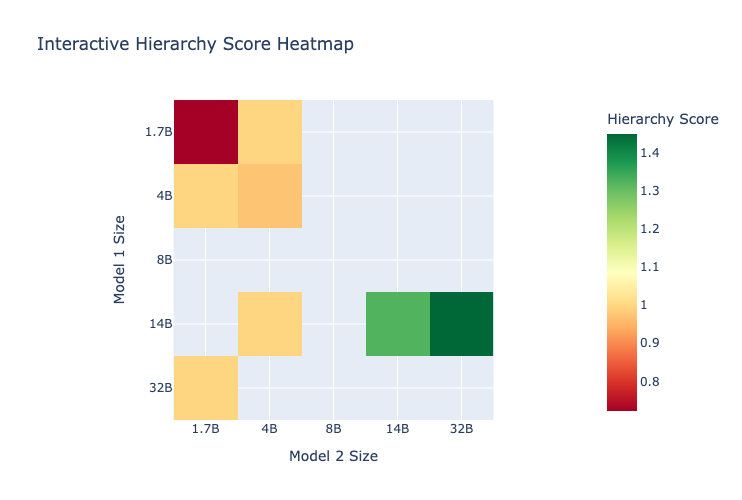

In [46]:
# 3. Interactive Heatmap with Plotly
fig = px.imshow(
    hierarchy_matrix.values,
    x=hierarchy_matrix.columns,
    y=hierarchy_matrix.index,
    color_continuous_scale='RdYlGn',
    title='Interactive Hierarchy Score Heatmap',
    labels={'x': 'Model 2 Size', 'y': 'Model 1 Size', 'color': 'Hierarchy Score'}
)

fig.update_layout(height=500)
fig.show()


## 3. Stacked Bar Charts and Distributions


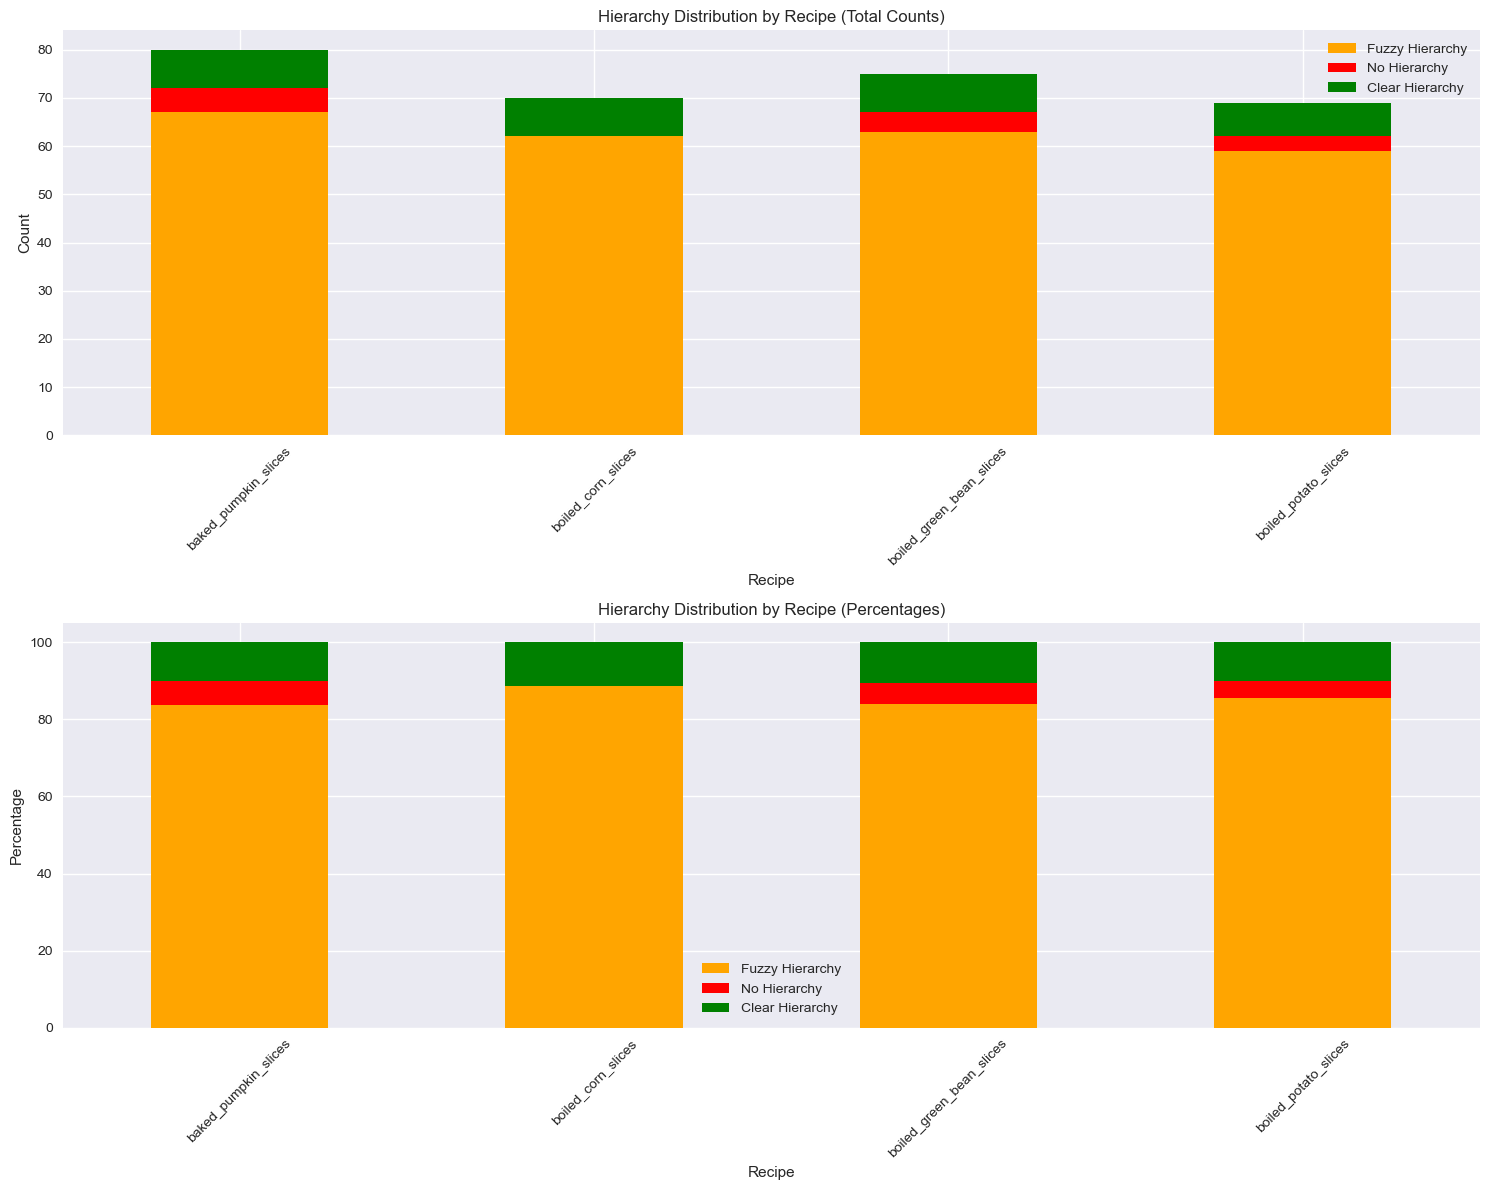

In [47]:
# 4. Stacked Bar Chart by Recipe
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Aggregate by recipe
recipe_agg = df.groupby('recipe')[['fuzzy_hierarchy', 'no_hierarchy', 'clear_hierarchy']].sum()

recipe_agg.plot(kind='bar', stacked=True, ax=axes[0], 
                color=['orange', 'red', 'green'])
axes[0].set_title('Hierarchy Distribution by Recipe (Total Counts)')
axes[0].set_xlabel('Recipe')
axes[0].set_ylabel('Count')
axes[0].legend(['Fuzzy Hierarchy', 'No Hierarchy', 'Clear Hierarchy'])
axes[0].tick_params(axis='x', rotation=45)

# Percentage version
recipe_pct = recipe_agg.div(recipe_agg.sum(axis=1), axis=0) * 100
recipe_pct.plot(kind='bar', stacked=True, ax=axes[1], 
                color=['orange', 'red', 'green'])
axes[1].set_title('Hierarchy Distribution by Recipe (Percentages)')
axes[1].set_xlabel('Recipe')
axes[1].set_ylabel('Percentage')
axes[1].legend(['Fuzzy Hierarchy', 'No Hierarchy', 'Clear Hierarchy'])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


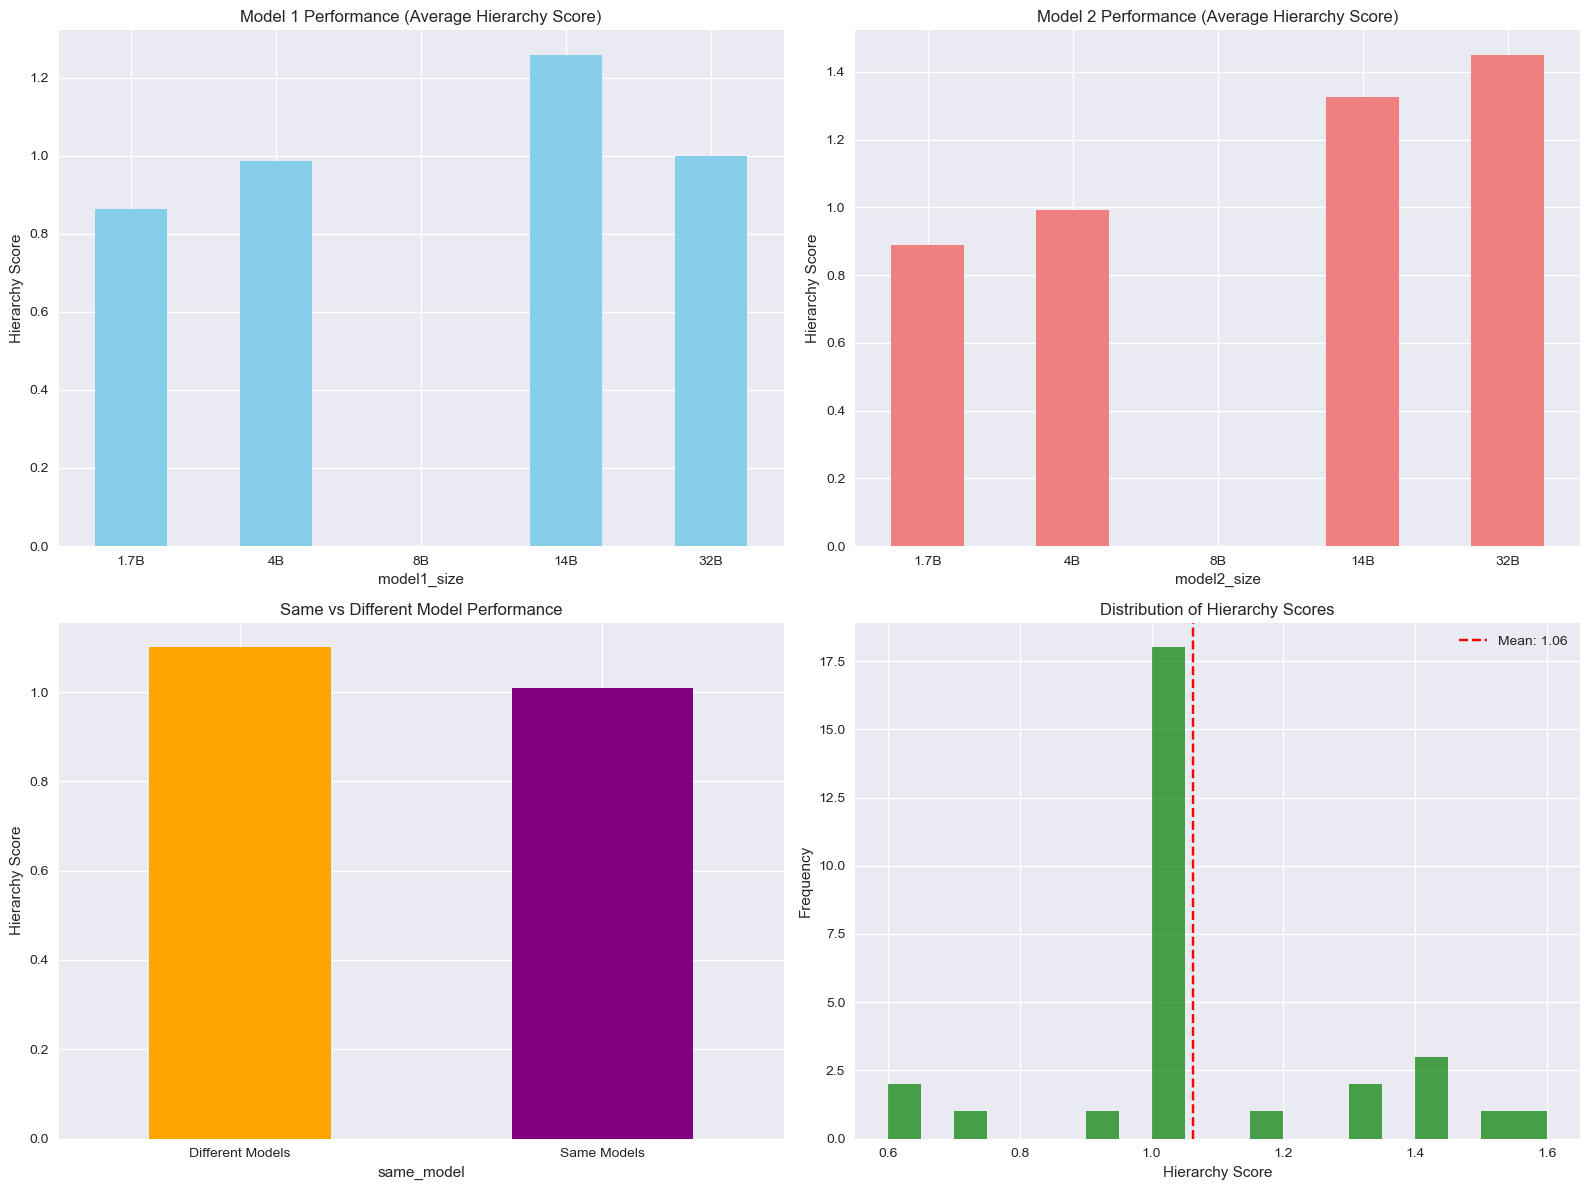

In [48]:
# 5. Model Size Performance Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Model 1 performance (ordered by size)
model1_perf = df.groupby('model1_size')['hierarchy_score'].mean().reindex(model_size_order)
model1_perf.plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Model 1 Performance (Average Hierarchy Score)')
axes[0,0].set_ylabel('Hierarchy Score')
axes[0,0].tick_params(axis='x', rotation=0)

# Model 2 performance (ordered by size)
model2_perf = df.groupby('model2_size')['hierarchy_score'].mean().reindex(model_size_order)
model2_perf.plot(kind='bar', ax=axes[0,1], color='lightcoral')
axes[0,1].set_title('Model 2 Performance (Average Hierarchy Score)')
axes[0,1].set_ylabel('Hierarchy Score')
axes[0,1].tick_params(axis='x', rotation=0)

# Same vs Different Models
same_diff = df.groupby('same_model')['hierarchy_score'].mean()
same_diff.plot(kind='bar', ax=axes[1,0], color=['orange', 'purple'])
axes[1,0].set_title('Same vs Different Model Performance')
axes[1,0].set_ylabel('Hierarchy Score')
axes[1,0].set_xticklabels(['Different Models', 'Same Models'], rotation=0)

# Distribution of hierarchy scores
df['hierarchy_score'].hist(bins=20, ax=axes[1,1], alpha=0.7, color='green')
axes[1,1].set_title('Distribution of Hierarchy Scores')
axes[1,1].set_xlabel('Hierarchy Score')
axes[1,1].set_ylabel('Frequency')
axes[1,1].axvline(df['hierarchy_score'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {df["hierarchy_score"].mean():.2f}')
axes[1,1].legend()

plt.tight_layout()
plt.show()


## 4. Network and Relationship Visualizations


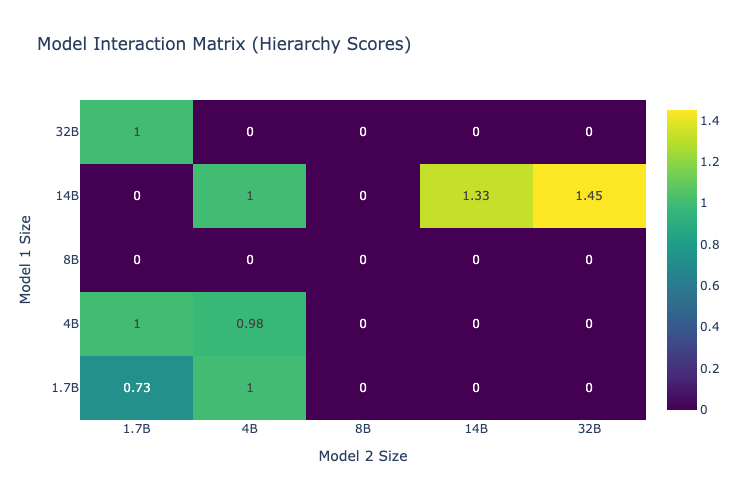

In [49]:
# 6. Chord Diagram using Plotly
# Create a matrix for model relationships with proper ordering
model_sizes = model_size_order
n_models = len(model_sizes)

# Create interaction matrix
interaction_matrix = np.zeros((n_models, n_models))
for i, m1 in enumerate(model_sizes):
    for j, m2 in enumerate(model_sizes):
        score = df[(df['model1_size'] == m1) & (df['model2_size'] == m2)]['hierarchy_score'].mean()
        interaction_matrix[i, j] = score if not np.isnan(score) else 0

# Create chord diagram using plotly
fig = go.Figure(data=go.Heatmap(
    z=interaction_matrix,
    x=model_sizes,
    y=model_sizes,
    colorscale='Viridis',
    text=np.round(interaction_matrix, 2),
    texttemplate="%{text}",
    textfont={"size": 12},
    hoverongaps=False
))

fig.update_layout(
    title='Model Interaction Matrix (Hierarchy Scores)',
    xaxis_title='Model 2 Size',
    yaxis_title='Model 1 Size',
    height=500
)

fig.show()


## 5. Statistical Analysis and Clustering


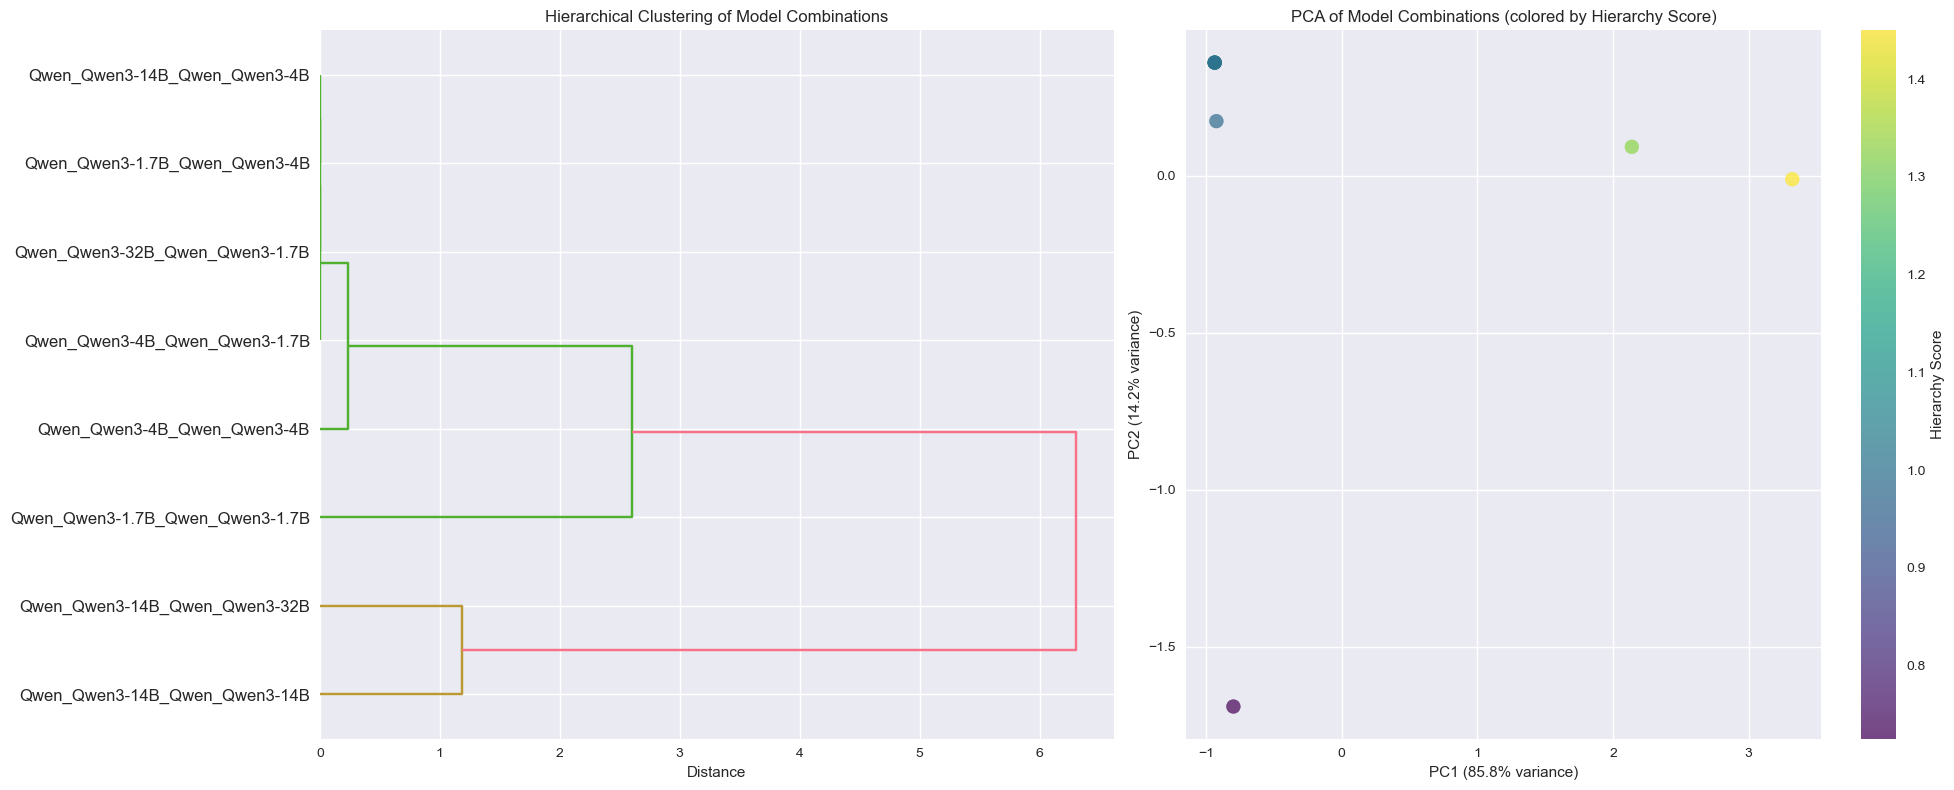

PCA explains 100.0% of total variance


In [50]:
# 7. Hierarchical Clustering of Model Combinations
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Prepare data for clustering
clustering_data = df.pivot_table(
    values=['fuzzy_pct', 'clear_pct', 'hierarchy_score'], 
    index='model_combination', 
    aggfunc='mean'
).fillna(0)

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_data)

# Perform hierarchical clustering
linkage_matrix = linkage(scaled_data, method='ward')

# Create dendrogram
dendrogram(linkage_matrix, labels=clustering_data.index, ax=axes[0], orientation='right')
axes[0].set_title('Hierarchical Clustering of Model Combinations')
axes[0].set_xlabel('Distance')

# PCA visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

scatter = axes[1].scatter(pca_data[:, 0], pca_data[:, 1], 
                         c=clustering_data['hierarchy_score'], 
                         cmap='viridis', s=100, alpha=0.7)
axes[1].set_title('PCA of Model Combinations (colored by Hierarchy Score)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')

# Add colorbar
plt.colorbar(scatter, ax=axes[1], label='Hierarchy Score')

# Add labels for interesting points
for i, model in enumerate(clustering_data.index):
    if clustering_data.iloc[i]['hierarchy_score'] > 1.5 or clustering_data.iloc[i]['hierarchy_score'] < 0.5:
        axes[1].annotate(model.replace('Qwen_Qwen3-', '').replace('_Qwen_Qwen3-', '_'), 
                        (pca_data[i, 0], pca_data[i, 1]), 
                        xytext=(5, 5), textcoords='offset points', 
                        fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

print(f"PCA explains {pca.explained_variance_ratio_.sum():.1%} of total variance")


## 6. Advanced Interactive Visualizations


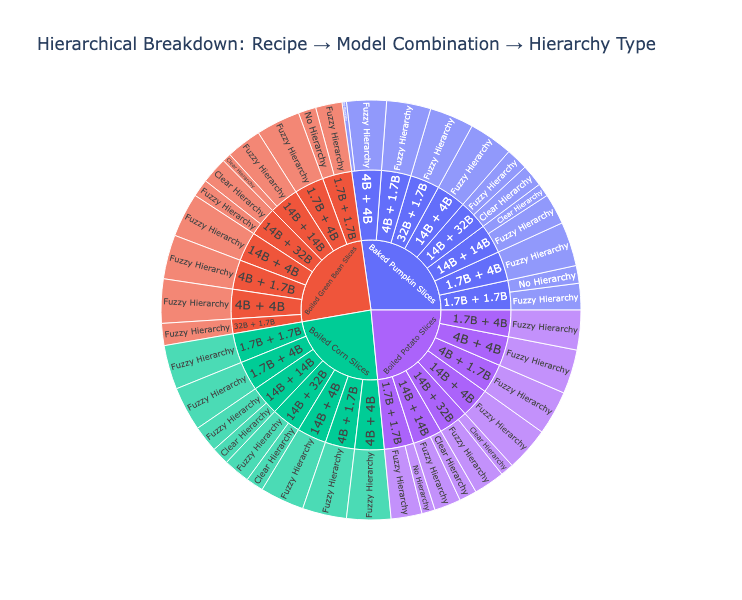

In [51]:
# 8. Interactive Sunburst Chart
# Prepare data for sunburst
sunburst_data = []

for _, row in df.iterrows():
    recipe = row['recipe'].replace('_', ' ').title()
    model_combo = f"{row['model1_size']} + {row['model2_size']}"
    
    # Add entries for each hierarchy type
    for hierarchy_type in ['fuzzy_hierarchy', 'no_hierarchy', 'clear_hierarchy']:
        count = row[hierarchy_type]
        if count > 0:
            sunburst_data.extend([
                {
                    'ids': f"{recipe}",
                    'labels': recipe,
                    'parents': "",
                    'values': count
                },
                {
                    'ids': f"{recipe} - {model_combo}",
                    'labels': model_combo,
                    'parents': recipe,
                    'values': count
                },
                {
                    'ids': f"{recipe} - {model_combo} - {hierarchy_type}",
                    'labels': hierarchy_type.replace('_', ' ').title(),
                    'parents': f"{recipe} - {model_combo}",
                    'values': count
                }
            ])

# Remove duplicates and aggregate
sunburst_df = pd.DataFrame(sunburst_data)
sunburst_df = sunburst_df.groupby(['ids', 'labels', 'parents'])['values'].sum().reset_index()

fig = go.Figure(go.Sunburst(
    ids=sunburst_df['ids'],
    labels=sunburst_df['labels'],
    parents=sunburst_df['parents'],
    values=sunburst_df['values'],
    branchvalues="total",
    maxdepth=3
))

fig.update_layout(
    title="Hierarchical Breakdown: Recipe → Model Combination → Hierarchy Type",
    height=600
)

fig.show()


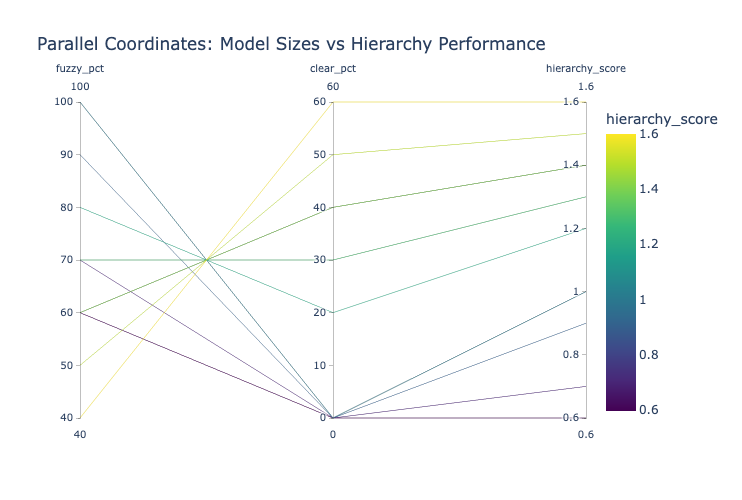

In [52]:
# 9. Interactive Parallel Coordinates Plot
# Prepare data for parallel coordinates
parallel_df = df.copy()
parallel_df['model1_size_num'] = parallel_df['model1_size'].map({
    '1.7B': 1.7, '4B': 4, '8B': 8, '14B': 14, '32B': 32
})
parallel_df['model2_size_num'] = parallel_df['model2_size'].map({
    '1.7B': 1.7, '4B': 4, '8B': 8, '14B': 14, '32B': 32
})

fig = px.parallel_coordinates(
    parallel_df,
    dimensions=['model1_size_num', 'model2_size_num', 'fuzzy_pct', 'clear_pct', 'hierarchy_score'],
    color='hierarchy_score',
    color_continuous_scale='Viridis',
    title='Parallel Coordinates: Model Sizes vs Hierarchy Performance'
)

fig.update_layout(height=500)
fig.show()


## 7. Summary Statistics and Insights


In [54]:
# 10. Summary Statistics and Key Insights
print("=" * 80)
print("HIERARCHY ANALYSIS SUMMARY REPORT")
print("=" * 80)

# Overall statistics
total_experiments = df['total_outcomes'].sum()
avg_hierarchy_score = df['hierarchy_score'].mean()

print(f"\n📊 OVERALL STATISTICS")
print(f"Total experiments analyzed: {total_experiments:,}")
print(f"Average hierarchy score: {avg_hierarchy_score:.3f}")
print(f"Recipes tested: {df['recipe'].nunique()}")
print(f"Model combinations tested: {df['model_combination'].nunique()}")

# Best performing combinations
print(f"\n🏆 TOP PERFORMING MODEL COMBINATIONS")
top_combos = df.nlargest(5, 'hierarchy_score')[['model_combination', 'recipe', 'hierarchy_score', 'clear_pct']]
for idx, row in top_combos.iterrows():
    print(f"  {row['model_combination']:40} | {row['recipe']:20} | Score: {row['hierarchy_score']:.3f} | Clear: {row['clear_pct']:.1f}%")

# Worst performing combinations
print(f"\n🔻 LOWEST PERFORMING MODEL COMBINATIONS")
worst_combos = df.nsmallest(5, 'hierarchy_score')[['model_combination', 'recipe', 'hierarchy_score', 'fuzzy_pct']]
for idx, row in worst_combos.iterrows():
    print(f"  {row['model_combination']:40} | {row['recipe']:20} | Score: {row['hierarchy_score']:.3f} | Fuzzy: {row['fuzzy_pct']:.1f}%")

# Model size analysis with proper ordering
print(f"\n🔍 MODEL SIZE PERFORMANCE")
model1_ranking = df.groupby('model1_size')['hierarchy_score'].mean().reindex(model_size_order)
model2_ranking = df.groupby('model2_size')['hierarchy_score'].mean().reindex(model_size_order)

print("Model 1 (Leader) Performance:")
for size, score in model1_ranking.items():
    print(f"  {size:>5}: {score:.3f}")

print("\nModel 2 (Follower) Performance:")
for size, score in model2_ranking.items():
    print(f"  {size:>5}: {score:.3f}")

# Recipe difficulty analysis
print(f"\n🍳 RECIPE DIFFICULTY RANKING")
recipe_difficulty = df.groupby('recipe')['hierarchy_score'].mean().sort_values(ascending=False)
for recipe, score in recipe_difficulty.items():
    difficulty = "Easy" if score > 1.5 else "Medium" if score > 1.0 else "Hard"
    print(f"  {recipe:25} | Score: {score:.3f} | Difficulty: {difficulty}")

# Same vs different model analysis
print(f"\n🤝 SAME VS DIFFERENT MODEL ANALYSIS")
same_model_perf = df[df['same_model']]['hierarchy_score'].mean()
diff_model_perf = df[~df['same_model']]['hierarchy_score'].mean()
print(f"Same model combinations: {same_model_perf:.3f}")
print(f"Different model combinations: {diff_model_perf:.3f}")
print(f"Difference: {diff_model_perf - same_model_perf:.3f} ({'Better' if diff_model_perf > same_model_perf else 'Worse'} with different models)")

print("\n" + "=" * 80)
print("END OF REPORT")
print("=" * 80)


HIERARCHY ANALYSIS SUMMARY REPORT

📊 OVERALL STATISTICS
Total experiments analyzed: 294
Average hierarchy score: 1.063
Recipes tested: 4
Model combinations tested: 8

🏆 TOP PERFORMING MODEL COMBINATIONS
  Qwen_Qwen3-14B_Qwen_Qwen3-32B            | boiled_green_bean_slices | Score: 1.600 | Clear: 60.0%
  Qwen_Qwen3-14B_Qwen_Qwen3-32B            | baked_pumpkin_slices | Score: 1.500 | Clear: 50.0%
  Qwen_Qwen3-14B_Qwen_Qwen3-14B            | boiled_corn_slices   | Score: 1.400 | Clear: 40.0%
  Qwen_Qwen3-14B_Qwen_Qwen3-32B            | boiled_corn_slices   | Score: 1.400 | Clear: 40.0%
  Qwen_Qwen3-14B_Qwen_Qwen3-14B            | boiled_potato_slices | Score: 1.400 | Clear: 40.0%

🔻 LOWEST PERFORMING MODEL COMBINATIONS
  Qwen_Qwen3-1.7B_Qwen_Qwen3-1.7B          | baked_pumpkin_slices | Score: 0.600 | Fuzzy: 60.0%
  Qwen_Qwen3-1.7B_Qwen_Qwen3-1.7B          | boiled_green_bean_slices | Score: 0.600 | Fuzzy: 60.0%
  Qwen_Qwen3-1.7B_Qwen_Qwen3-1.7B          | boiled_potato_slices | Score: 0.

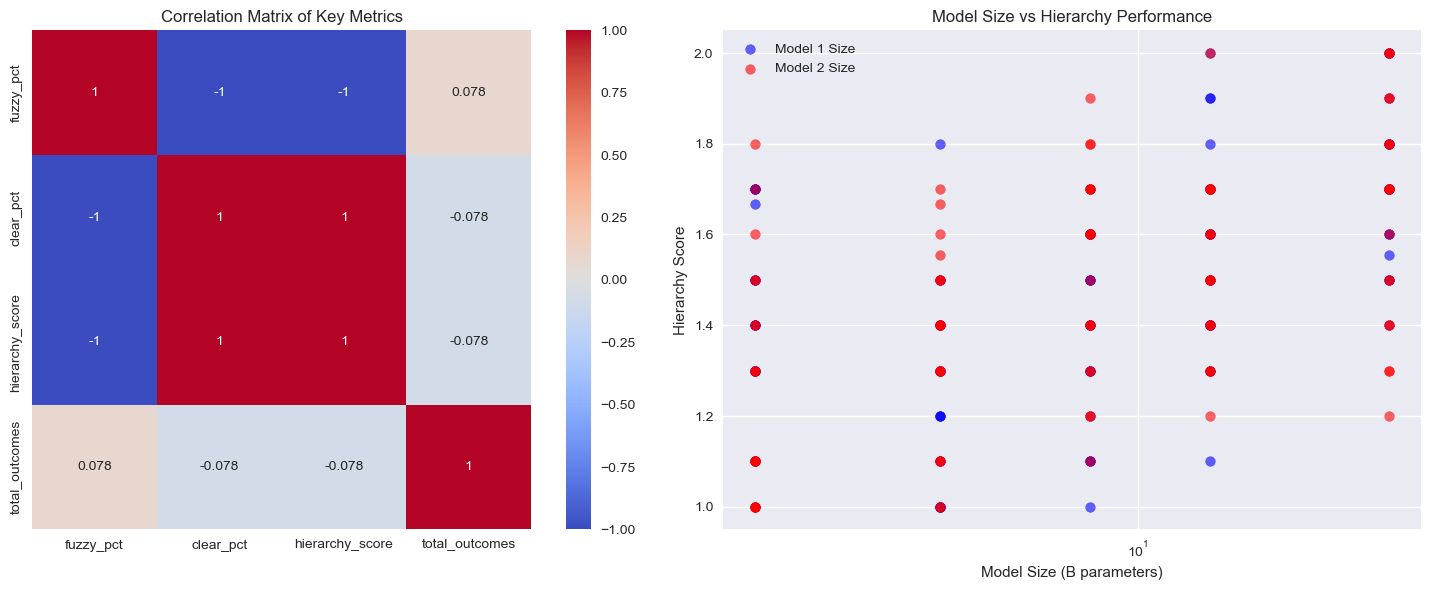

Correlation between model1 size and hierarchy score: 0.5667761235508089
Correlation between model2 size and hierarchy score: 0.4713343464978107


In [39]:
# 11. Correlation Analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Correlation matrix of key metrics
corr_cols = ['fuzzy_pct', 'clear_pct', 'hierarchy_score', 'total_outcomes']
correlation_matrix = df[corr_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            ax=axes[0], square=True)
axes[0].set_title('Correlation Matrix of Key Metrics')

# Model size correlation
model_corr_data = df.copy()
model_corr_data['model1_size_num'] = model_corr_data['model1_size'].map({
    '1.7B': 1.7, '4B': 4, '8B': 8, '14B': 14, '32B': 32
})
model_corr_data['model2_size_num'] = model_corr_data['model2_size'].map({
    '1.7B': 1.7, '4B': 4, '8B': 8, '14B': 14, '32B': 32
})

axes[1].scatter(model_corr_data['model1_size_num'], model_corr_data['hierarchy_score'], 
               alpha=0.6, label='Model 1 Size', color='blue')
axes[1].scatter(model_corr_data['model2_size_num'], model_corr_data['hierarchy_score'], 
               alpha=0.6, label='Model 2 Size', color='red')
axes[1].set_xlabel('Model Size (B parameters)')
axes[1].set_ylabel('Hierarchy Score')
axes[1].set_title('Model Size vs Hierarchy Performance')
axes[1].legend()
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

print("Correlation between model1 size and hierarchy score:", 
      model_corr_data[['model1_size_num', 'hierarchy_score']].corr().iloc[0,1])
print("Correlation between model2 size and hierarchy score:", 
      model_corr_data[['model2_size_num', 'hierarchy_score']].corr().iloc[0,1])
